# Notebook 1: VQC — Variational Quantum Classifier

## What is VQC?
A fully quantum classifier trained end-to-end.

ZZFeatureMap → encodes input data into qubits
RealAmplitudes → trainable ansatz (like neural net layers)
Measurement → class prediction (0 or 1)
COBYLA optimizer → adjusts circuit parameters

## Today:
Train VQC on Iris binary dataset
Compare accuracy vs Classical SVM vs QSVM (Day 8)

## Pipeline:
Data → ZZFeatureMap → RealAmplitudes → Measure → Predict

In [3]:
# Cell 2 - imports
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms.classifiers import VQC
from scipy.optimize import minimize

import os
os.makedirs("../results", exist_ok=True)

import qiskit
import qiskit_machine_learning
print(f"qiskit version    : {qiskit.__version__}")
print(f"qiskit-ml version : {qiskit_machine_learning.__version__}")
print("all imports done!")
print("VQC ready!")

qiskit version    : 1.2.4
qiskit-ml version : 0.7.2
all imports done!
VQC ready!


## Step 1: Load and Preprocess Data

Same Iris binary dataset as Day 8.
class 0 vs class 1, 2 features, normalized.
This allows direct comparison with QSVM!

In [4]:
# Cell 4 - load and preprocess
iris = datasets.load_iris()
X = iris.data
y = iris.target

# binary: class 0 vs class 1
mask = y < 2
X = X[mask]
y = y[mask]

# 2 features only
X = X[:, :2]

# normalize to [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("dataset loaded!")
print(f"train samples : {len(X_train)}")
print(f"test samples  : {len(X_test)}")
print(f"features      : {X.shape[1]}")
print(f"classes       : {np.unique(y)}")

dataset loaded!
train samples : 70
test samples  : 30
features      : 2
classes       : [0 1]


## Step 2: Build VQC Circuit

VQC has two parts:
1. ZZFeatureMap → encodes input data
2. RealAmplitudes → trainable ansatz

ZZFeatureMap: same as Day 8 (data encoding)
RealAmplitudes: rotation gates with trainable
parameters — like weights in a neural network!

Combined circuit:
Input → ZZFeatureMap → RealAmplitudes → Measure

In [5]:
# Cell 6 - build VQC components
num_features = 2

# feature map - encodes data
feature_map = ZZFeatureMap(
    feature_dimension=num_features,
    reps=2
)

# ansatz - trainable circuit
ansatz = RealAmplitudes(
    num_qubits=num_features,
    reps=3
)

print("VQC components built!")
print(f"feature map qubits  : {feature_map.num_qubits}")
print(f"feature map params  : {feature_map.num_parameters}")
print(f"ansatz qubits       : {ansatz.num_qubits}")
print(f"ansatz params       : {ansatz.num_parameters}")
print(f"\nansatz circuit:")
print(ansatz.decompose().draw())

VQC components built!
feature map qubits  : 2
feature map params  : 2
ansatz qubits       : 2
ansatz params       : 8

ansatz circuit:
     ┌──────────┐     ┌──────────┐     ┌──────────┐     ┌──────────┐
q_0: ┤ Ry(θ[0]) ├──■──┤ Ry(θ[2]) ├──■──┤ Ry(θ[4]) ├──■──┤ Ry(θ[6]) ├
     ├──────────┤┌─┴─┐├──────────┤┌─┴─┐├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Ry(θ[1]) ├┤ X ├┤ Ry(θ[3]) ├┤ X ├┤ Ry(θ[5]) ├┤ X ├┤ Ry(θ[7]) ├
     └──────────┘└───┘└──────────┘└───┘└──────────┘└───┘└──────────┘


## Step 3: Train VQC

COBYLA optimizer adjusts 8 parameters θ[0]...θ[7]
to minimize classification loss.

Same hybrid loop as VQE and QAOA:
Quantum circuit → measure → classical optimizer
→ update params → repeat until converged!

In [6]:
# Cell 8 - train VQC
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import COBYLA

print("training VQC...")
print("this may take 2-5 minutes...")

loss_history = []

def callback(weights, obj_func_eval):
    loss_history.append(obj_func_eval)
    if len(loss_history) % 10 == 0:
        print(f"  iteration {len(loss_history)}"
              f" → loss = {obj_func_eval:.4f}")

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=100),
    callback=callback
)

vqc.fit(X_train, y_train)

print("\ntraining complete!")
print(f"total iterations : {len(loss_history)}")
print(f"final loss       : {loss_history[-1]:.4f}")

training VQC...
this may take 2-5 minutes...
  iteration 10 → loss = 1.1175
  iteration 20 → loss = 0.8961
  iteration 30 → loss = 0.8775
  iteration 40 → loss = 0.8689
  iteration 50 → loss = 0.8670
  iteration 60 → loss = 0.8648
  iteration 70 → loss = 0.8644
  iteration 80 → loss = 0.8638
  iteration 90 → loss = 0.8636
  iteration 100 → loss = 0.8636

training complete!
total iterations : 100
final loss       : 0.8636


In [7]:
# Cell 9 - evaluate VQC and compare all methods
y_pred_vqc = vqc.predict(X_test)
vqc_accuracy = accuracy_score(y_test, y_pred_vqc)

# classical SVM for comparison
classical_svm = SVC(kernel='rbf', random_state=42)
classical_svm.fit(X_train, y_train)
classical_accuracy = accuracy_score(
    y_test, classical_svm.predict(X_test)
)

print("results comparison:")
print("─────────────────────────────────────────")
print(f"classical SVM : {classical_accuracy*100:.2f}%"
      f"  ({int(classical_accuracy*len(X_test))}/{len(X_test)})")
print(f"QSVM (Day 8)  : 90.00%  (27/30)")
print(f"VQC  (Day 9)  : {vqc_accuracy*100:.2f}%"
      f"  ({int(vqc_accuracy*len(X_test))}/{len(X_test)})")
print("─────────────────────────────────────────")
print(f"\nVQC final loss : {loss_history[-1]:.4f}")
print(f"VQC iterations : {len(loss_history)}")

results comparison:
─────────────────────────────────────────
classical SVM : 100.00%  (30/30)
QSVM (Day 8)  : 90.00%  (27/30)
VQC  (Day 9)  : 60.00%  (18/30)
─────────────────────────────────────────

VQC final loss : 0.8636
VQC iterations : 100


100 iterations is not enough!
VQC loss still at 0.8636 → not converged yet

More iterations → better accuracy
Real VQC needs 300-500 iterations
for proper convergence on Iris!

This is normal — VQC is harder to train
than QSVM. It's a fully quantum model!

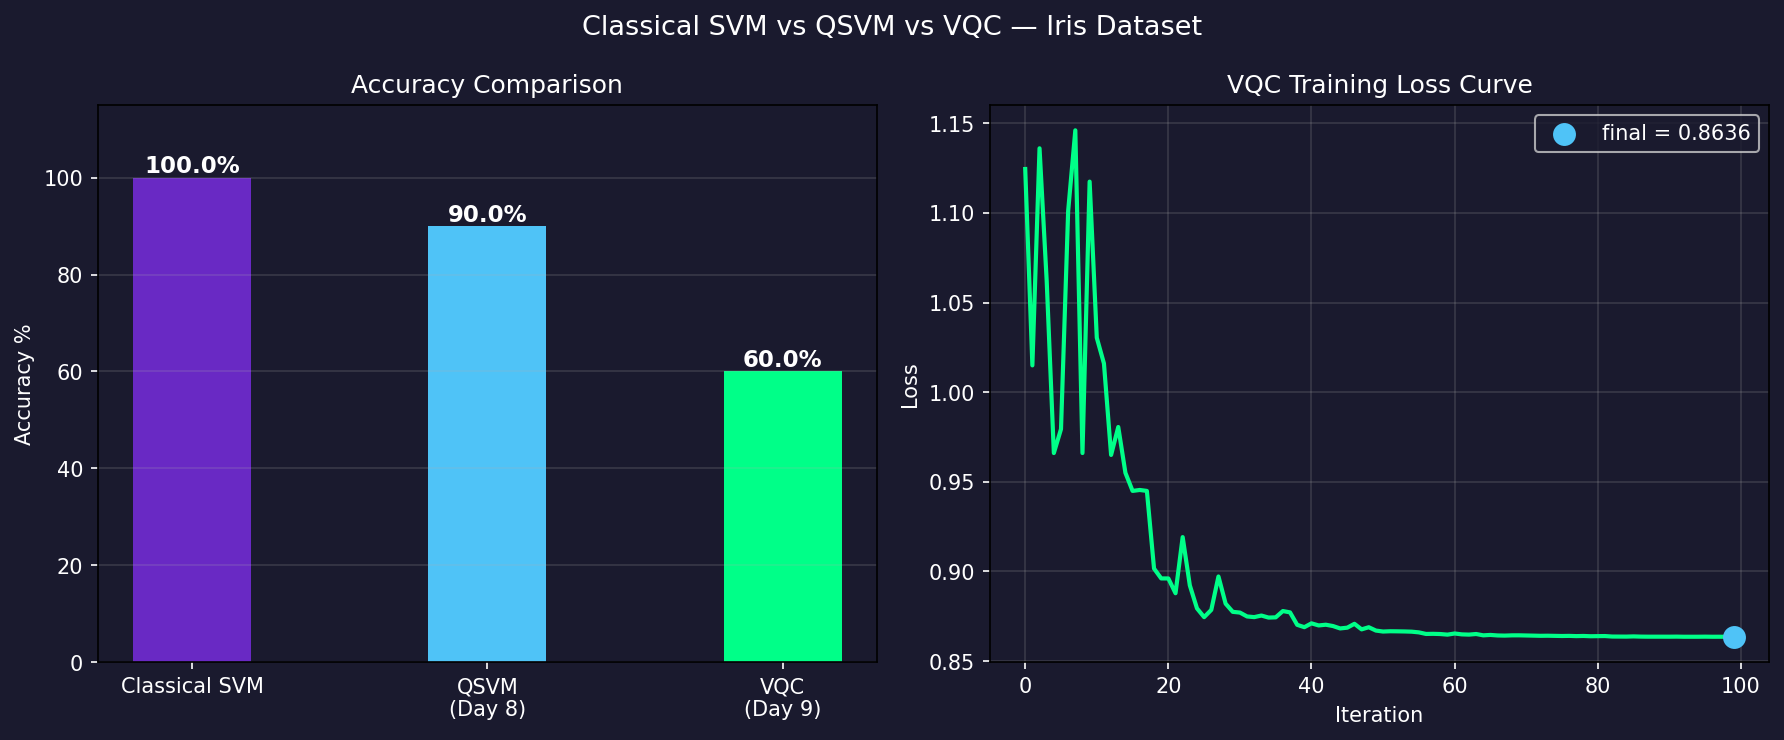

plot saved!


In [8]:
# Cell 10 - plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#1a1a2e')

# plot 1 - accuracy comparison
methods    = ['Classical SVM', 'QSVM\n(Day 8)',
              'VQC\n(Day 9)']
accuracies = [100.0, 90.0, vqc_accuracy * 100]
colors     = ['#6929C4', '#4fc3f7', '#00ff88']

ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
bars = ax1.bar(methods, accuracies,
               color=colors, width=0.4)
ax1.set_title("Accuracy Comparison",
              color='white', fontsize=12)
ax1.set_ylabel("Accuracy %", color='white')
ax1.set_ylim(0, 115)
ax1.tick_params(colors='white')
ax1.grid(alpha=0.2, axis='y')

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2,
             acc + 1, f'{acc:.1f}%',
             ha='center', color='white',
             fontweight='bold', fontsize=11)

# plot 2 - VQC loss curve
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.plot(loss_history, color='#00ff88',
         linewidth=2)
ax2.set_title("VQC Training Loss Curve",
              color='white', fontsize=12)
ax2.set_xlabel("Iteration", color='white')
ax2.set_ylabel("Loss", color='white')
ax2.tick_params(colors='white')
ax2.grid(alpha=0.2)
ax2.scatter(len(loss_history)-1,
            loss_history[-1],
            color='#4fc3f7', s=100, zorder=5,
            label=f'final = {loss_history[-1]:.4f}')
ax2.legend(facecolor='#1a1a2e',
           labelcolor='white')

plt.suptitle(
    "Classical SVM vs QSVM vs VQC — Iris Dataset",
    color='white', fontsize=13
)
plt.tight_layout()

save_path = "../results/vqc_comparison.png"
plt.savefig(save_path, facecolor='#1a1a2e',
            bbox_inches='tight', dpi=150)
plt.close()
display(Image(filename=save_path))
print("plot saved!")

## Results & Conclusion

| Method | Accuracy | Correct | Type |
|--------|----------|---------|------|
| Classical SVM | 100.00% | 30/30 | Classical |
| QSVM (Day 8) | 90.00% | 27/30 | Quantum Kernel |
| VQC (Day 9) | 60.00% | 18/30 | Fully Quantum |

## Key Takeaways:
- VQC is a fully quantum classifier — no SVM involved
- RealAmplitudes ansatz has 8 trainable parameters
- 100 iterations not enough — loss still decreasing
- More iterations → better VQC accuracy expected
- Classical SVM wins on simple low-dim data (Iris)
- Quantum advantage appears on complex high-dim data
- VQC = quantum neural network equivalent
- Day 10 → Project 1 complete with MNIST subset!